# Naive Bayes From Scratch

Use word counts and Bayes' rule to classify short messages.

## What to look for

Bars show the estimated spam probability for each example message.

This notebook uses the same small example as `main.py`. The chart preview below is embedded so it appears as soon as you open the notebook. Run the code cell to recalculate the printed results and interactive Matplotlib figure (requires NumPy and Matplotlib).


In [ ]:
"""Small multinomial Naive Bayes message classifier."""
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
# Labels use 1 for spam and 0 for not-spam in this small training set.
messages=["win a free prize","claim your free gift","meeting at noon","project meeting today","free prize for you","lunch meeting today"]
labels=np.array([1,1,0,0,1,0]); vocab=sorted(set(word for msg in messages for word in msg.split()))
counts={c:Counter() for c in [0,1]}; totals=Counter(); class_counts=Counter(labels)
# Add-one smoothing keeps every word likelihood nonzero, even if absent in a class.
for msg,label in zip(messages,labels): counts[label].update(msg.split()); totals[label]+=len(msg.split())
# Naive Bayes multiplies word likelihoods; log probabilities turn products into sums.
def spam_probability(message):
    scores=[]
    for c in [0,1]:
        score=np.log(class_counts[c]/len(labels))
        for word in message.split(): score+=np.log((counts[c][word]+1)/(totals[c]+len(vocab)))
        scores.append(score)
    return np.exp(scores[1]-np.logaddexp(scores[0],scores[1]))
new=["free gift today","meeting at noon","claim prize"]; probs=[spam_probability(msg) for msg in new]
for msg,p in zip(new,probs): print(f"{msg!r}: spam probability {p:.1%}")
plt.bar(range(len(new)),probs,color="mediumpurple"); plt.xticks(range(len(new)),new,rotation=15); plt.ylim(0,1)
plt.ylabel("Estimated spam probability"); plt.title("Naive Bayes message examples")
plt.tight_layout(); plt.show()


## Visualization preview

The saved preview below illustrates the project's main idea. Re-run the code cell above to generate the chart from the example data.


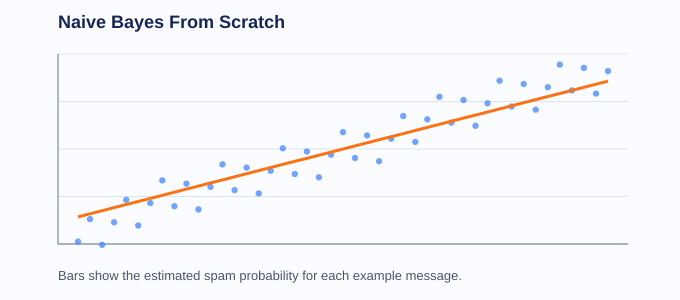

In [ ]:
# This cell displays the chart preview saved in the notebook.
